##### Load Required Libraries

In [7]:
# !pip install watermark numpy pandas matplotlib torch torchvision torchaudio --yes

%load_ext watermark
%watermark -v -p watermark,numpy,pandas,matplotlib,torch

#
import math,random,os,copy,time,glob,itertools,shutil,re, json
from scipy.stats import wilcoxon

#
import numpy as np

#
import torch
import torch.nn as nn
import torch.nn.functional as tf
from torch.utils.data import Dataset,DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor, Lambda

#
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif", # sans-serif
    "font.sans-serif": "Helvetica", # Times, Palatino, Computer Modern Roman
})
from mpl_toolkits import mplot3d

#
import pandas as pd


#
from demofcns import *
from opts.asgm.torchlasgm import PID
from opts.elpf.fo import LPF
from opts.elpf.sfo import sLPF

from arcs.resnet import ResNetC

worker_seed = 2023
def setseed(inc=0):
    # for redundancy
    # set seed for technical reproducibility
    myseed = worker_seed + inc
    random.seed(myseed)
    np.random.seed(myseed)
    np.random.default_rng(myseed)
    torch.manual_seed(myseed)    
    
    # torch.use_deterministic_algorithms(True)
    if torch.cuda.device_count() > 0:
      torch.cuda.manual_seed_all(myseed)
      torch.cuda.manual_seed(myseed)
      # torch.backends.cudnn.enabled = True
      # torch.backends.cuda.matmul.allow_tf32 = False
      # torch.backends.cudnn.benchmark = False
      # torch.backends.cudnn.deterministic = False
      # torch.backends.cudnn.allow_tf32 = True



class cseed_worker():
  def __init__(self,inc=0):
    self.inc = inc
    
  def seed_worker(self,workerid):
    np.random.seed(worker_seed+self.inc)
    random.seed(worker_seed+self.inc)

cseedwk = cseed_worker()

# python3 -m torch.utils.collect_env

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.10.6
IPython version      : 8.4.0

watermark : 2.3.1
numpy     : 1.23.2
pandas    : 1.4.3
matplotlib: 3.5.3
torch     : 1.12.1+cu116



##### Setup Configurations (Hyperparameters and so on)

In [8]:
# - is it being run remotely on OSU EECS server?
remotelyrun = 0 # 0 | 1

#----------------------
# Load setup config
#----------------------
with open('cfgs.json', 'r') as cfglist:
  cfgs = json.load(cfglist)
  
# setup
cfgs['storedir'] = "expstore"

# - pick data-set
cfgs["dataset"] = "fmnist"
# - set max. batchsize for each epoch, training runs, training epochs, 
cfgs["batch-size"] = 128 # 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, ...
cfgs['runs'] = 10
cfgs["epochs"] = 30

# -pick computation device
devcnt = torch.cuda.device_count()

# - setup multiprocessing, human signature
# random seed for python libraries
cfgs["seed"] = 2023
cfgs["var_seed"] = 1
worker_seed = cfgs["seed"] % (2**32)
cfgs["num-workers"] = 0 #3
cfgs["human_signature"] = "oas" # for signing experiments ran.


if devcnt > 1:
  cfgs["device"] = torch.device('cuda') # "cuda:1"
  torch.cuda.set_device(1)
elif devcnt == 1:
  cfgs["device"] = torch.device('cuda')
else:
  cfgs["device"] = torch.device('cpu')
#
if remotelyrun:
  cfgs["remote"] = True
else:
  cfgs["remote"] = False
  

##### Construct Model (Differentiable Function) with  necessary methods.

In [9]:
'''
Uses ResNetC
'''

class thisNN(nn.Module):
  def __init__(self,num_heads=1,in_feats=[1,28,28],out_feats=10,layers=6, loss_type="mce", outs_class=True, mdl_name="nnresnet") -> None:
    """
    __init__ _summary_

    _extended_summary_

    Args:
        num_heads (int, req): net. output head. Defaults to 1.
        in_feats (int, req): net. input dimension. Defaults to 1.
        out_feats (int, req): net. output dimension per head. Defaults to 1.
        loss_type (str, req): type of loss function Defaults to "mse". ("mse","mce" for multi-class cross-entropy, "bce" binary-class cross-entropy)
        outs_class (bool, req): does model return class indices. Defaults to False, implying it outputs real-valued probabilities. This is also true for loss_type="mse" regardless of user-choice.
    """
    super().__init__()
    self.num_heads = num_heads
    
    # define mdl. params.
    self.cnn = nn.ModuleList()
    for hid in range(num_heads): 
      self.cnn.append(
        ResNetC(in_chans=in_feats[0],stem_chans=64,layers=str(layers),botneck=False,num_classes=out_feats,num_heads=num_heads) 
      )
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    
    # prob.fcn at last output or network head layer
    if loss_type == "bce" or loss_type == "mse":
      self.out = torch.nn.Sigmoid()
    else:
      self.out = torch.nn.Softmax()
    
    self.loss_type = loss_type
    self.outs_class = outs_class
    
    # optimizer
    self.sgm = None
    
    # saved trained model
    self.chkpt = None
    
    
    self.devcnt = torch.cuda.device_count()
    self.device = None
    self.name = mdl_name+str(layers)
    
    if not(loss_type == "mse" or loss_type =="mce" or loss_type == "bce"):
      raise ValueError(f"loss_type='{loss_type}' is not defined for this class")
    if (loss_type == "mse"):
      self.outs_class = False    
    
@clsmethod(thisNN)
def forward(self:thisNN, x):
  # pre-process
  logits = []
  for hid in range(self.num_heads):
    resnet = self.cnn[hid]
    y = resnet(x)  
    logits.append(y)
    
  return logits # List [Tensor]

@clsmethod(thisNN)
def outhead(self:thisNN, x):
  probs = []
  for hid in range(self.num_heads):
    y = self.out(x[hid])
    probs.append(y)  
  return probs # List [Tensor]

# Add necessary functions to train model
add_to_thisnn(thisNN,worker_seed,setseed,cseedwk)

# Use saved mdl as
# mdl <-- load model function
# prediction = mdl.infer(input)

##### (Generate) or Load the Dataset

In [10]:
#----------------------
# Download/Load Dataset
#----------------------
if not cfgs["remote"]:
  # same dir. as source-code
  data_folder = "data"
else:
  # dalton's scratch on OSU's eecs server
  data_folder = "/scratch/data"


# FMNIST
if cfgs["dataset"] == "fmnist":
  train_data = datasets.FashionMNIST(
    root=data_folder,
    train=True,
    download=True,
    transform=ToTensor(),
  )
  test_data = datasets.FashionMNIST(
    root=data_folder,
    train=False,
    download= True,
    transform=ToTensor()
  )
  indim = [28,28]
  class_num = 10
  channels = 1
  val_data = None
  
# Tests 
trainloader = torch.utils.data.DataLoader(train_data, batch_size=cfgs['batch-size'],shuffle=True)
# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)
pass

##### Run the Network Modeling (Training) 

In [11]:
# Test.

torch.manual_seed(2023)
devcnt = torch.cuda.device_count()

cfgs['mdl_name_dir'] = "nnresnet6_botneck_none_fixedss"
isclassifier = True
cfgs["ss_init"] = 1e-3 # default 1e-3
cfgs["eps_ss"] = 1. # default 5e-1
cfgs["weight_decay"] = 1e-5 # default 1e-5
mdl = thisNN(mdl_name=cfgs['mdl_name_dir'])
if devcnt > 0:
    mdl.cuda()
cfgs['pathstr'] = str(mdl.name)+str(cfgs["batch-size"])+"_"+cfgs["dataset"]+"_"+str(cfgs["runs"])+"_"+str(cfgs["epochs"])

mdl.runs(train_data, test_data, cfgs=cfgs, eval_name="Test")

Seed: 2023
**************************************************************************************************************************************************
aSGM info:
[step-size or linear correlation value (starting := 0.001), (ending := 0), step-size pole : 1],
[LPF Poles [i,n,o] : 0.9, 0.999, 1e-05]
**************************************************************************************************************************************************

1: Elapsed Train time: 0.32-mins.
Batches/Steps/Iterations per Epoch:   469
Train:	[ Avg Loss: 0.5000, Accuracy: 82.43% ] || Test: [ Avg Loss: 0.4029, Accuracy: 86.06% ]
Elapsed Inf. time: 0.02-mins.
 
2: Elapsed Train time: 0.31-mins.
Batches/Steps/Iterations per Epoch:   469
Train:	[ Avg Loss: 0.3069, Accuracy: 88.87% ] || Test: [ Avg Loss: 0.3537, Accuracy: 87.45% ]
Elapsed Inf. time: 0.02-mins.
 
3: Elapsed Train time: 0.35-mins.
Batches/Steps/Iterations per Epoch:   469
Train:	[ Avg Loss: 0.2569, Accuracy: 90.74% ] || Test: [ Avg Loss: 

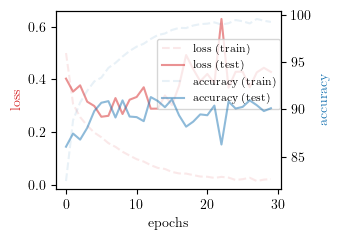

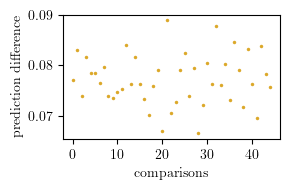

In [12]:
# Plots
plotter_v1(cfgs,run_idx=1)